In [0]:
%pip install numpy==1.22.4 --force-reinstall
%pip install scipy==1.7.3 --force-reinstall
%pip install matplotlib==3.7.1 --force-reinstall
%pip install tensorflow==2.12.0 --force-reinstall
%pip install prophet seaborn
%pip install xgboost pyspark


Python interpreter will be restarted.
  Using cached numpy-1.22.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.3.0 requires numpy>=1.23, but you have numpy 1.22.4 which is incompatible.
Python interpreter will be restarted.
Python interpreter will be restarted.
  Using cached scipy-1.7.3-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (39.8 MB)
  Using cached numpy-1.22.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4
  Attempting uninstall: scipy
    Foun

In [0]:
from pyspark.sql.functions import col, expr, lead, isnan, mean, min, max
from pyspark.sql import Window
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
# from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from pyspark.ml.functions import vector_to_array

from statsmodels.tsa.stattools import grangercausalitytests
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

### Preprocessing on the NVDA and AMD Prices

In [0]:
df_nvda = spark.sql("SELECT * FROM nvidia_data")
display(df_nvda.limit(5))

Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,Trailing_PE_NVDA,Forward_PE_NVDA,Total_Revenue_NVDA,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA
1999-01-22,0.0376117043197155,0.0447753115840147,0.0355814649774072,0.040118782563947,2714688000,before_trump,null,null,0.012793096707386225,0.009129054446532888,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-25,0.0415520668029785,0.0420289058282125,0.0376117140461148,0.0405965508934446,510480000,before_trump,null,null,0.014133356055434865,0.010085453107519054,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-26,0.0383278876543045,0.0428652059573384,0.0377309182952898,0.042028901596367,343200000,before_trump,null,null,0.013036696481055952,0.009302885352986527,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-27,0.0382086783647537,0.0394026137342712,0.0362976500460264,0.0384470978668602,244368000,before_trump,null,null,0.012996149103657722,0.009273951059406238,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-28,0.0380885563790798,0.0384471029006281,0.0378501368457577,0.038208683367306,227520000,before_trump,null,null,0.012955291285401292,0.009244795237640727,130497003520,null,0.0,0.0,1,1,0,1,null


In [0]:
df_amd = spark.sql("SELECT * FROM amd_data")
display(df_amd.limit(5))

Date,Close_AMD,High_AMD,Low_AMD,Open_AMD,Volume_AMD,Period_AMD,Shares_Out_AMD,Market_Cap_AMD,Trailing_PE_AMD,Forward_PE_AMD,Total_Revenue_AMD,PS_Ratio_AMD,Total_Debt_AMD,Cash_Equivalents_AMD,TD_CE_Missing_AMD,Shares_Out_Missing_AMD,PE_Missing_AMD,PS_Missing_AMD,EV_AMD
1999-01-20,11.0,11.21875,10.375,11.0625,10568400,before_trump,null,null,11.0,2.1568627450980395,25784999936,null,0.0,0.0,1,1,0,1,null
1999-01-21,10.5,10.625,9.875,10.4375,13118200,before_trump,null,null,10.5,2.058823529411765,25784999936,null,0.0,0.0,1,1,0,1,null
1999-01-22,10.78125,11.03125,10.3125,10.375,9179000,before_trump,null,null,10.78125,2.1139705882352944,25784999936,null,0.0,0.0,1,1,0,1,null
1999-01-25,10.71875,11.25,10.6875,11.0625,7139000,before_trump,null,null,10.71875,2.10171568627451,25784999936,null,0.0,0.0,1,1,0,1,null
1999-01-26,11.0,11.25,10.6875,10.875,4653600,before_trump,null,null,11.0,2.1568627450980395,25784999936,null,0.0,0.0,1,1,0,1,null


In [0]:
df_nvda.count()

Out[4]: 6586

In [0]:
df_amd.count()

Out[5]: 6541

In [0]:
# combining the 2 stocks based on date
df_combined = df_amd.join(df_nvda, on="Date", how="inner")

Split the dataset between training and test
- Training is everything before 2020-12-31
- Test is everything after 2021-01-04 (Stock market is open on holidays so skips to Jan 4th)

In [0]:
df_stocks = df_combined.filter("Date <= '2020-12-31'")
df_stocks_test = df_combined.filter("Date >= '2021-01-04'")


In [0]:
df_stocks.count()

Out[8]: 5523

In [0]:
df_stocks.columns

Out[9]: ['Date',
 'Close_AMD',
 'High_AMD',
 'Low_AMD',
 'Open_AMD',
 'Volume_AMD',
 'Period_AMD',
 'Shares_Out_AMD',
 'Market_Cap_AMD',
 'Trailing_PE_AMD',
 'Forward_PE_AMD',
 'Total_Revenue_AMD',
 'PS_Ratio_AMD',
 'Total_Debt_AMD',
 'Cash_Equivalents_AMD',
 'TD_CE_Missing_AMD',
 'Shares_Out_Missing_AMD',
 'PE_Missing_AMD',
 'PS_Missing_AMD',
 'EV_AMD',
 'Close_NVDA',
 'High_NVDA',
 'Low_NVDA',
 'Open_NVDA',
 'Volume_NVDA',
 'Period_NVDA',
 'Shares_Out_NVDA',
 'Market_Cap_NVDA',
 'Trailing_PE_NVDA',
 'Forward_PE_NVDA',
 'Total_Revenue_NVDA',
 'PS_Ratio_NVDA',
 'Total_Debt_NVDA',
 'Cash_Equivalents_NVDA',
 'TD_CE_Missing_NVDA',
 'Shares_Out_Missing_NVDA',
 'PE_Missing_NVDA',
 'PS_Missing_NVDA',
 'EV_NVDA']

In [0]:
display(df_stocks.limit(5))

Date,Close_AMD,High_AMD,Low_AMD,Open_AMD,Volume_AMD,Period_AMD,Shares_Out_AMD,Market_Cap_AMD,Trailing_PE_AMD,Forward_PE_AMD,Total_Revenue_AMD,PS_Ratio_AMD,Total_Debt_AMD,Cash_Equivalents_AMD,TD_CE_Missing_AMD,Shares_Out_Missing_AMD,PE_Missing_AMD,PS_Missing_AMD,EV_AMD,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,Trailing_PE_NVDA,Forward_PE_NVDA,Total_Revenue_NVDA,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA
1999-01-22,10.78125,11.03125,10.3125,10.375,9179000,before_trump,null,null,10.78125,2.1139705882352944,25784999936,null,0.0,0.0,1,1,0,1,null,0.0376117043197155,0.0447753115840147,0.0355814649774072,0.040118782563947,2714688000,before_trump,null,null,0.012793096707386225,0.009129054446532888,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-25,10.71875,11.25,10.6875,11.0625,7139000,before_trump,null,null,10.71875,2.10171568627451,25784999936,null,0.0,0.0,1,1,0,1,null,0.0415520668029785,0.0420289058282125,0.0376117140461148,0.0405965508934446,510480000,before_trump,null,null,0.014133356055434865,0.010085453107519054,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-26,11.0,11.25,10.6875,10.875,4653600,before_trump,null,null,11.0,2.1568627450980395,25784999936,null,0.0,0.0,1,1,0,1,null,0.0383278876543045,0.0428652059573384,0.0377309182952898,0.042028901596367,343200000,before_trump,null,null,0.013036696481055952,0.009302885352986527,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-27,10.625,11.125,10.59375,11.0625,3121600,before_trump,null,null,10.625,2.0833333333333335,25784999936,null,0.0,0.0,1,1,0,1,null,0.0382086783647537,0.0394026137342712,0.0362976500460264,0.0384470978668602,244368000,before_trump,null,null,0.012996149103657722,0.009273951059406238,130497003520,null,0.0,0.0,1,1,0,1,null
1999-01-28,11.4375,11.5,10.90625,11.0,9317200,before_trump,null,null,11.4375,2.2426470588235294,25784999936,null,0.0,0.0,1,1,0,1,null,0.0380885563790798,0.0384471029006281,0.0378501368457577,0.038208683367306,227520000,before_trump,null,null,0.012955291285401292,0.009244795237640727,130497003520,null,0.0,0.0,1,1,0,1,null


In [0]:
# see if the total revenue has any variation in values - if not, leave in the 'cols_to_drop' 
unique_count = df_stocks.select('Total_Revenue_NVDA').distinct().count()
print(f"Number of unique values: {unique_count}")

Number of unique values: 1


In [0]:
cols_to_drop = ['Period_AMD','Shares_Out_AMD','Market_Cap_AMD','PS_Ratio_AMD','Total_Debt_AMD','Cash_Equivalents_AMD','TD_CE_Missing_AMD','Shares_Out_Missing_AMD','PE_Missing_AMD','PS_Missing_AMD','EV_AMD','Period_NVDA','Shares_Out_NVDA','Market_Cap_NVDA','PS_Ratio_NVDA','Total_Debt_NVDA','Cash_Equivalents_NVDA','TD_CE_Missing_NVDA','Shares_Out_Missing_NVDA','PE_Missing_NVDA','PS_Missing_NVDA','EV_NVDA', 'Total_Revenue_NVDA', 'Total_Revenue_AMD']
df_stocks = df_stocks.drop(*cols_to_drop)

# this code was used to test NVDA against itself
# cols_to_drop = ['Period_NVDA','Shares_Out_NVDA','Market_Cap_NVDA','PS_Ratio_NVDA','Total_Debt_NVDA','Cash_Equivalents_NVDA','TD_CE_Missing_NVDA','Shares_Out_Missing_NVDA','PE_Missing_NVDA','PS_Missing_NVDA','EV_NVDA', 'Total_Revenue_NVDA']
# df_stocks = df_stocks.drop(*cols_to_drop)

In [0]:
df_stocks_test = df_stocks_test.drop(*cols_to_drop)

In [0]:
df_stocks.columns

Out[14]: ['Date',
 'Close_AMD',
 'High_AMD',
 'Low_AMD',
 'Open_AMD',
 'Volume_AMD',
 'Trailing_PE_AMD',
 'Forward_PE_AMD',
 'Close_NVDA',
 'High_NVDA',
 'Low_NVDA',
 'Open_NVDA',
 'Volume_NVDA',
 'Trailing_PE_NVDA',
 'Forward_PE_NVDA']

In [0]:
df_stocks_test.columns

Out[15]: ['Date',
 'Close_AMD',
 'High_AMD',
 'Low_AMD',
 'Open_AMD',
 'Volume_AMD',
 'Trailing_PE_AMD',
 'Forward_PE_AMD',
 'Close_NVDA',
 'High_NVDA',
 'Low_NVDA',
 'Open_NVDA',
 'Volume_NVDA',
 'Trailing_PE_NVDA',
 'Forward_PE_NVDA']

In [0]:
# list of columns that should be numeric
numeric_cols = ['Close_AMD','High_AMD','Low_AMD','Open_AMD','Volume_AMD','Trailing_PE_AMD','Forward_PE_AMD','Close_NVDA','High_NVDA','Low_NVDA','Open_NVDA','Volume_NVDA','Trailing_PE_NVDA','Forward_PE_NVDA']
# numeric_cols = ['Close_NVDA','High_NVDA','Low_NVDA','Open_NVDA','Volume_NVDA','Trailing_PE_NVDA','Forward_PE_NVDA']

# cast the columsn to make sur ethey are all the correct type (Double)
for col_name in numeric_cols:
    df_stocks = df_stocks.withColumn(col_name, df_stocks[col_name].cast(DoubleType()))
    df_stocks_test = df_stocks_test.withColumn(col_name, df_stocks_test[col_name].cast(DoubleType()))

### Feature Engineering
Compute the differences in AMD and NVDA features

In [0]:
df_stocks = df_stocks.withColumn("Close_Diff", col("Close_NVDA") - col("Close_AMD")) \
    .withColumn("Open_Diff", col("Open_NVDA") - col("Open_AMD")) \
    .withColumn("High_Diff", col("High_NVDA") - col("High_AMD")) \
    .withColumn("Low_Diff", col("Low_NVDA") - col("Low_AMD")) \
    .withColumn("Volume_Diff", col("Volume_NVDA") - col("Volume_AMD"))

df_stocks_test = df_stocks_test.withColumn("Close_Diff", col("Close_NVDA") - col("Close_AMD")) \
    .withColumn("Open_Diff", col("Open_NVDA") - col("Open_AMD")) \
    .withColumn("High_Diff", col("High_NVDA") - col("High_AMD")) \
    .withColumn("Low_Diff", col("Low_NVDA") - col("Low_AMD")) \
    .withColumn("Volume_Diff", col("Volume_NVDA") - col("Volume_AMD"))

Creating the target variables - the returns for both stocks

In [0]:
window = Window.orderBy("Date")
df_stocks = df_stocks.withColumn("prev_close_amd", F.lag("Close_AMD").over(window)) \
       .withColumn("return_amd", (F.col("Close_AMD") - F.col("prev_close_amd")) / F.col("prev_close_amd")) \
       .withColumn("prev_close_nvda", F.lag("Close_NVDA").over(window)) \
       .withColumn("return_nvda", (F.col("Close_NVDA") - F.col("prev_close_nvda")) / F.col("prev_close_nvda"))

window = Window.orderBy("Date")
df_stocks_test = df_stocks_test.withColumn("prev_close_amd", F.lag("Close_AMD").over(window)) \
       .withColumn("return_amd", (F.col("Close_AMD") - F.col("prev_close_amd")) / F.col("prev_close_amd")) \
       .withColumn("prev_close_nvda", F.lag("Close_NVDA").over(window)) \
       .withColumn("return_nvda", (F.col("Close_NVDA") - F.col("prev_close_nvda")) / F.col("prev_close_nvda"))

# window = Window.orderBy("Date")
# df_stocks = df_stocks.withColumn("prev_close_nvda", F.lag("Close_NVDA").over(window)) \
#        .withColumn("return_nvda", (F.col("Close_NVDA") - F.col("prev_close_nvda")) / F.col("prev_close_nvda"))

# window = Window.orderBy("Date")
# df_stocks_test = df_stocks_test.withColumn("prev_close_nvda", F.lag("Close_NVDA").over(window)) \
#        .withColumn("return_nvda", (F.col("Close_NVDA") - F.col("prev_close_nvda")) / F.col("prev_close_nvda"))

In [0]:
w = Window.orderBy("Date")

# Add the next days return to the row
df_stocks = df_stocks.withColumn("target_nvda_return", lead("return_nvda", 1).over(w))
df_stocks = df_stocks.withColumn("target_amd_return", lead("return_amd", 1).over(w))

In [0]:
w = Window.orderBy("Date")

df_stocks_test = df_stocks_test.withColumn("target_nvda_return", lead("return_nvda", 1).over(w))
df_stocks_test = df_stocks_test.withColumn("target_amd_return", lead("return_amd", 1).over(w))

In [0]:
display(df_stocks)

Date,Close_AMD,High_AMD,Low_AMD,Open_AMD,Volume_AMD,Trailing_PE_AMD,Forward_PE_AMD,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Trailing_PE_NVDA,Forward_PE_NVDA,Close_Diff,Open_Diff,High_Diff,Low_Diff,Volume_Diff,prev_close_amd,return_amd,prev_close_nvda,return_nvda,target_nvda_return,target_amd_return
1999-01-22,10.78125,11.03125,10.3125,10.375,9179000.0,10.78125,2.1139705882352944,0.0376117043197155,0.0447753115840147,0.0355814649774072,0.040118782563947,2.714688E9,0.012793096707386225,0.009129054446532888,-10.743638295680285,-10.334881217436052,-10.986474688415985,-10.276918535022594,2.705509E9,null,null,null,null,0.1047642630009064,-0.005797101449275362
1999-01-25,10.71875,11.25,10.6875,11.0625,7139000.0,10.71875,2.10171568627451,0.0415520668029785,0.0420289058282125,0.0376117140461148,0.0405965508934446,5.1048E8,0.014133356055434865,0.010085453107519054,-10.677197933197021,-11.021903449106555,-11.207971094171787,-10.649888285953885,5.03341E8,10.78125,-0.005797101449275362,0.0376117043197155,0.1047642630009064,-0.07759371306273727,0.026239067055393587
1999-01-26,11.0,11.25,10.6875,10.875,4653600.0,11.0,2.1568627450980395,0.0383278876543045,0.0428652059573384,0.0377309182952898,0.042028901596367,3.432E8,0.013036696481055952,0.009302885352986527,-10.961672112345695,-10.832971098403632,-11.20713479404266,-10.64976908170471,3.385464E8,10.71875,0.026239067055393587,0.0415520668029785,-0.07759371306273727,-0.003110249399236252,-0.03409090909090909
1999-01-27,10.625,11.125,10.59375,11.0625,3121600.0,10.625,2.0833333333333335,0.0382086783647537,0.0394026137342712,0.0362976500460264,0.0384470978668602,2.44368E8,0.012996149103657722,0.009273951059406238,-10.586791321635246,-11.024052902133139,-11.085597386265729,-10.557452349953973,2.412464E8,11.0,-0.03409090909090909,0.0383278876543045,-0.003110249399236252,-0.003143840373832798,0.07647058823529412
1999-01-28,11.4375,11.5,10.90625,11.0,9317200.0,11.4375,2.2426470588235294,0.0380885563790798,0.0384471029006281,0.0378501368457577,0.038208683367306,2.2752E8,0.012955291285401292,0.009244795237640727,-11.39941144362092,-10.961791316632693,-11.461552897099372,-10.868399863154242,2.182028E8,10.625,0.07647058823529412,0.0382086783647537,-0.003143840373832798,-0.04701926847157292,0.00273224043715847
1999-01-29,11.46875,11.75,11.25,11.5625,6167600.0,11.46875,2.248774509803922,0.0362976603209972,0.0382086891806895,0.0362976603209972,0.0380885621741862,2.44032E8,0.01234614296632558,0.00881011172839738,-11.432452339679003,-11.524411437825814,-11.71179131081931,-11.213702339679003,2.378644E8,11.4375,0.00273224043715847,0.0380885563790798,-0.04701926847157292,0.019755471783005917,0.08446866485013624
1999-02-01,12.4375,12.71875,12.15625,12.46875,1.77976E7,12.4375,2.4387254901960786,0.0370147377252578,0.0372531571934193,0.0362976448781443,0.0362976448781443,1.54704E8,0.012590046845325782,0.008984159642052863,-12.400485262274742,-12.432452355121855,-12.681496842806581,-12.119952355121855,1.369064E8,11.46875,0.08446866485013624,0.0362976603209972,0.019755471783005917,-0.07741855228848962,-0.022613065326633167
1999-02-02,12.15625,12.65625,11.96875,12.53125,6877800.0,12.15625,2.383578431372549,0.0341491103172302,0.0372531581280111,0.033074386532865,0.0362976457887646,2.64096E8,0.011615343645316394,0.008288619009036456,-12.12210088968277,-12.494952354211236,-12.618996841871988,-11.935675613467135,2.572182E8,12.4375,-0.022613065326633167,0.0370147377252578,-0.07741855228848962,0.020971694474164936,-0.13881748071979436
1999-02-03,10.46875,12.25,10.0,12.0,2.54876E7,10.46875,2.0526960784313726,0.0348652750253677,0.0353430327297823,0.0334320053282171,0.0336713436449501,7.512E7,0.011858937083458402,0.008462445394506723,-10.433884724974632,-11.96632865635505,-12.214656967270217,-9.966567994671783,4.96324E7,12.15625,-0.13881748071979436,0.0341491103172302,0.020971694474164936,0.05478639130614897,-0.0955223880597015
1999-02-04,9.46875,9.5,8.75,8.875,2.54402E7,9.46875,1.8566176470588236,0.036775417625904,0

In [0]:
display(df_stocks_test)

Date,Close_AMD,High_AMD,Low_AMD,Open_AMD,Volume_AMD,Trailing_PE_AMD,Forward_PE_AMD,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Trailing_PE_NVDA,Forward_PE_NVDA,Close_Diff,Open_Diff,High_Diff,Low_Diff,Volume_Diff,prev_close_amd,return_amd,prev_close_nvda,return_nvda,target_nvda_return,target_amd_return
2021-01-04,92.3000030517578,96.05999755859376,90.91999816894533,92.11000061035156,5.18026E7,92.3000030517578,18.09803981407016,13.07909870147705,13.61668524042548,12.928494800361127,13.069873279195663,5.6064E8,4.448673027713283,3.1745385197759832,-79.22090435028075,-79.0401273311559,-82.44331231816828,-77.9915033685842,5.088374E8,null,null,null,null,0.022209965868793966,0.0050920214059479085
2021-01-05,92.7699966430664,93.20999908447266,91.41000366210938,92.0999984741211,3.4208E7,92.7699966430664,18.1901954202091,13.369585037231444,13.408233079539716,13.05266861725504,13.065384842831412,3.2276E8,4.547477903820219,3.2450449119493796,-79.40041160583496,-79.03461363128969,-79.80176600493294,-78.35733504485434,2.88552E8,92.3000030517578,0.0050920214059479085,13.07909870147705,0.022209965868793966,-0.0589528117003277,-0.02630155115128052
2021-01-06,90.33000183105467,92.27999877929688,89.45999908447266,91.62000274658205,5.19117E7,90.33000183105467,17.711765064912683,12.58141040802002,13.210256356548374,12.552985563283952,13.187815339219432,5.80424E8,4.2793912952449045,3.053740390296121,-77.74859142303465,-78.43218740736262,-79.0697424227485,-76.9070135211887,5.285123E8,92.7699966430664,-0.02630155115128052,13.369585037231444,-0.0589528117003277,0.057830300627664144,0.0534706269583423
2021-01-07,95.16000366210938,95.51000213623048,91.1999969482422,91.33000183105467,4.28972E7,95.16000366210938,18.658824247472428,13.30899715423584,13.342659157109756,12.852697719234886,12.933484623786828,4.6148E8,4.526869780352326,3.230339115105786,-81.85100650787354,-78.39651720726785,-82.16734297912073,-78.34729922900732,4.185828E8,90.33000183105467,0.0534706269583423,12.58141040802002,0.057830300627664144,-0.0050398785567977444,-0.006095016905570441
2021-01-08,94.58000183105467,96.4000015258789,93.2699966430664,95.9800033569336,3.98164E7,94.58000183105467,18.545098398246015,13.241921424865724,13.385792937864828,13.007787437418736,13.327447059797182,2.92528E8,4.504054906416913,3.21405859826838,-81.33808040618895,-82.65255629713641,-83.01420858801407,-80.26220920564766,2.527116E8,95.16000366210938,-0.006095016905570441,13.30899715423584,-0.0050398785567977444,0.0259663535770309,0.028230049875814782
2021-01-11,97.25,99.2300033569336,93.76000213623048,94.02999877929688,4.86002E7,97.25,19.068627450980394,13.585765838623049,13.924375632075392,13.327445465368644,13.383547520576082,5.18344E8,4.621008788647296,3.2975159802483125,-83.66423416137695,-80.64645125872079,-85.3056277248582,-80.43255667086184,4.697438E8,94.58000183105467,0.028230049875814782,13.241921424865724,0.0259663535770309,-0.01003909388006562,-0.019434441024662595
2021-01-12,95.36000061035156,98.97000122070312,94.06999969482422,97.86000061035156,6.76723E7,95.36000061035156,18.698039335363053,13.449377059936523,13.71842005450195,13.309994119134457,13.716424494239064,2.91476E8,4.574618047597457,3.264411907751583,-81.91062355041504,-84.1435761161125,-85.25158116620118,-80.76000557568976,2.238037E8,97.25,-0.019434441024662595,13.585765838623049,-0.01003909388006562,0.0034851497167846085,-0.037541965269933836
2021-01-13,91.77999877929688,93.88999938964844,90.83999633789062,93.01000213623048,6.07129E7,91.77999877929688,17.996078192018995,13.49625015258789,13.589255791853278,13.349885642883663,13.454609726368211,2.10028E8,4.590561276390439,3.275788871987352,-78.28374862670898,-79.55539240986226,-80.30074359779516,-77.49011069500696,1.493151E8,95.36000061035156,-0.037541965269933836,13.449377059936523,0.0034851497167846085,-0.024497796894878153,-0.010786640629078418
2021-01-14,90.79000091552734,92.36000061035156,90.4499969482422,91.7699966430664,5.34082E7,90.79000091552734,17.801960963828893,13.

### Modeling
- Linear Regression - not expecting the data to be linear but a good to see how it performs
- LSTM - as the RNN got good results in the stock prediction, LSTM is expected to do pretty well also
- XGBoost - Recommened to try out. (post run: tested XGBoost given that LSTM didnt perform well)

In [0]:
def run_linear_regression(df_stocks, df_stocks_test, target):
    # gather all the features except the Date and the target
    feature_cols = [col for col in df_stocks.columns if col not in (target, "Date")]

    # remove all the nulls and nans from the data
    df_stocks = df_stocks.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks = df_stocks.filter(~isnan(col(c)))

    df_stocks_test = df_stocks_test.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks_test = df_stocks_test.filter(~isnan(col(c)))

    # define the assembler and add the features
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_features = assembler.transform(df_stocks)
    df_features_test = assembler.transform(df_stocks_test)

    # scale features
    scaler = MinMaxScaler(inputCol='features', outputCol="scaled_features")
    scaler_model = scaler.fit(df_features)

    df_scaled_train = scaler_model.transform(df_features)
    df_scaled_test = scaler_model.transform(df_features_test)

    # change the scaled vector to an array
    df_scaled_train = df_scaled_train.withColumn("scaled_features_array", vector_to_array("scaled_features"))
    df_scaled_test = df_scaled_test.withColumn("scaled_features_array", vector_to_array("scaled_features"))

    # fit the features into the 
    lr = LinearRegression(featuresCol="features", labelCol=target)
    lr_model = lr.fit(df_scaled_train)

    # run predictions on test
    predictions = lr_model.transform(df_scaled_test)

    # use evaluator to get metrics
    evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
    rmse = evaluator.evaluate(predictions)

    r2_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")
    r2 = r2_evaluator.evaluate(predictions)

    mae_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mae")
    mae = mae_evaluator.evaluate(predictions)

    # print metrics
    print(f"RMSE: {np.sqrt(rmse):.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")


Seeing if AMD affects NVDA

In [0]:
run_linear_regression(df_stocks, df_stocks_test, 'target_nvda_return')

RMSE: 0.2731, R²: -4.0172, MAE: 0.0473


Seeing if NVDA affects AMD

In [0]:
run_linear_regression(df_stocks, df_stocks_test, 'target_amd_return')

RMSE: 0.2742, R²: -4.6678, MAE: 0.0506


Getting basic stats to make sense of the metrics

In [0]:
result = df_stocks.select(
    mean("target_nvda_return").alias("mean_value"),
    min("target_nvda_return").alias("min_value"),
    max("target_nvda_return").alias("max_value")
).collect()[0]

# Access the results
mean_val = result["mean_value"]
min_val = result["min_value"]
max_val = result["max_value"]

print(f"Mean: {mean_val}, Min: {min_val}, Max: {max_val}")

Mean: 0.0017968859693254947, Min: -0.3523359557555399, Max: 0.42414734613910887


In [0]:
result = df_stocks.select(
    mean("target_amd_return").alias("mean_value"),
    min("target_amd_return").alias("min_value"),
    max("target_amd_return").alias("max_value")
).collect()[0]

# Access the results
mean_val = result["mean_value"]
min_val = result["min_value"]
max_val = result["max_value"]

print(f"Mean: {mean_val}, Min: {min_val}, Max: {max_val}")

Mean: 0.0011879097037545557, Min: -0.3240223106516899, Max: 0.5229008335186689


## LTSM

In [0]:
# helper function to help create windows
def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(target[i+window_size])
    return np.array(X), np.array(y)

In [0]:

def run_neural_network(df_stocks, df_stocks_test, target):
    # get features for prediction
    feature_cols = [col for col in df_stocks.columns if col not in (target, "Date")]

    # remove nan and nill rows
    df_stocks = df_stocks.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks = df_stocks.filter(~isnan(col(c)))

    df_stocks_test = df_stocks_test.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks_test = df_stocks_test.filter(~isnan(col(c)))

    # convert to vector
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_features = assembler.transform(df_stocks)
    df_features_test = assembler.transform(df_stocks_test)

    # scale features
    scaler = MinMaxScaler(inputCol='features', outputCol="scaled_features")
    scaler_model = scaler.fit(df_features)
    df_scaled_train = scaler_model.transform(df_features)
    df_scaled_test = scaler_model.transform(df_features_test)

    # change the scaled vector to an array
    df_scaled_train = df_scaled_train.withColumn("scaled_features_array", vector_to_array("scaled_features"))
    df_scaled_test = df_scaled_test.withColumn("scaled_features_array", vector_to_array("scaled_features"))

    # chnage to a pandas object
    df_pd = df_scaled_train.select("scaled_features_array", target).toPandas()
    df_pd_test = df_scaled_test.select("scaled_features_array", target).toPandas()

    # using a rolling window to create the train and test sets instead of using the predefined splits from before
    window_size = 60  # past X days
    X, y = create_sequences(
        np.stack(df_pd["scaled_features_array"].values), 
        df_pd[target].values,
        window_size
    )

    X_test, y_test = create_sequences(
        np.stack(df_pd["scaled_features_array"].values), 
        df_pd[target].values,
        window_size
    )

    # compose the LSTM
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=(window_size, len(feature_cols))))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    # adding early stopping for val loss
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X, y, epochs=20, batch_size=16, validation_data=(X_test, y_test))

    # predicting on the test set
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {np.sqrt(mse):.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")

In [0]:
run_neural_network(df_stocks, df_stocks_test, 'target_nvda_return')

Epoch 1/20
215/342 [=================>............] - ETA: 7s - loss: 0.0032

*** WARNING: max output size exceeded, skipping output. ***

171/171 [==============================] - 4s 19ms/step
RMSE: 0.0386, R²: -0.0066, MAE: 0.0256


In [0]:
run_neural_network(df_stocks, df_stocks_test, 'target_amd_return')

Epoch 1/20
280/342 [=======================>......]

*** WARNING: max output size exceeded, skipping output. ***

171/171 [==============================] - 4s 22ms/step
RMSE: 0.0406, R²: -0.0252, MAE: 0.0280


### XGBoost

In [0]:
def run_xgboost(df_stocks, df_stocks_test, target, target_ticker):
    feature_cols = [col for col in df_stocks.columns if col not in (target, "Date")]

    # remove nan and nill rows
    df_stocks = df_stocks.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks = df_stocks.filter(~isnan(col(c)))

    df_stocks_test = df_stocks_test.dropna(subset=feature_cols + [target])
    for c in feature_cols:
        df_stocks_test = df_stocks_test.filter(~isnan(col(c)))

    # convert to vector
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_features = assembler.transform(df_stocks)
    df_features_test = assembler.transform(df_stocks_test)

    # scale features
    scaler = MinMaxScaler(inputCol='features', outputCol="scaled_features")
    scaler_model = scaler.fit(df_features)
    df_scaled_train = scaler_model.transform(df_features)
    df_scaled_test = scaler_model.transform(df_features_test)

    df_scaled_train = df_scaled_train.withColumn("scaled_features_array", vector_to_array("scaled_features"))
    df_scaled_test = df_scaled_test.withColumn("scaled_features_array", vector_to_array("scaled_features"))

    # Prepare features
    df_pd = df_scaled_train.select("scaled_features_array", target).toPandas()
    df_pd_test = df_scaled_test.select("scaled_features_array", target).toPandas()

    # Split into X, y
    X = np.vstack(df_pd["scaled_features_array"])
    y = df_pd[target]

    X_test = np.vstack(df_pd_test["scaled_features_array"])
    y_test = df_pd_test[target]

    # Train using XGBoost
    model = XGBRegressor(    
        objective='reg:squarederror',
        n_estimators=300,             
        max_depth=6,                  
        learning_rate=0.01,           
        subsample=0.8,                
        colsample_bytree=0.8,        
        gamma=0,                     
        min_child_weight=1,           
        reg_alpha=0,                  
        reg_lambda=1,                 
        random_state=42
    )

    model.fit(X, y)

    # predict on the test data
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {np.sqrt(mse):.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")

    # Plot the results
    df_stocks_test_pd = df_stocks_test.toPandas()
    results_df = pd.DataFrame({
        'Date': pd.to_datetime(df_stocks_test_pd['Date']),
        'Actual': y_test.values,
        'Predicted': y_pred.flatten()  # if needed
    })

    plt.figure(figsize=(12, 6))
    plt.plot(results_df['Date'], results_df['Actual'], label="Actual")
    plt.plot(results_df['Date'], results_df['Predicted'], label="Predicted")
    plt.title("XGB Predictions vs Actual (AMD)")
    plt.xlabel("Date")
    plt.ylabel("Target NVDA Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Seeing if AMD affects NVDA

RMSE: 0.0240, R²: 0.4792, MAE: 0.0174


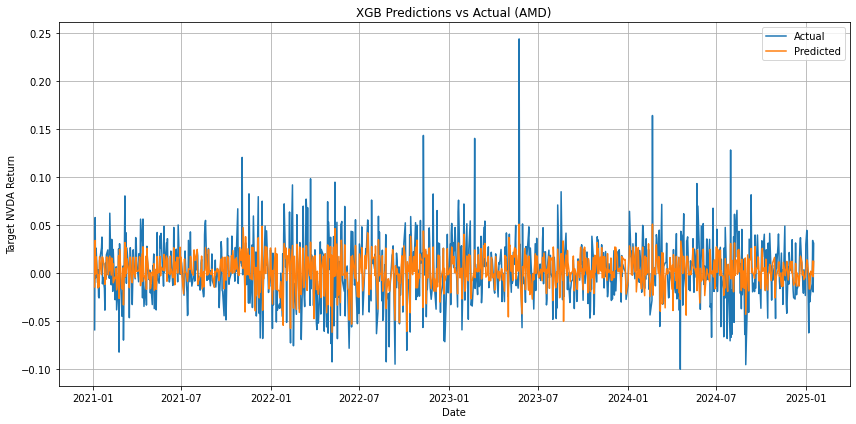

In [0]:
run_xgboost(df_stocks, df_stocks_test, 'target_nvda_return', "NVDA")

Seeing if NVDA affects AMD

RMSE: 0.0239, R²: 0.4286, MAE: 0.0171


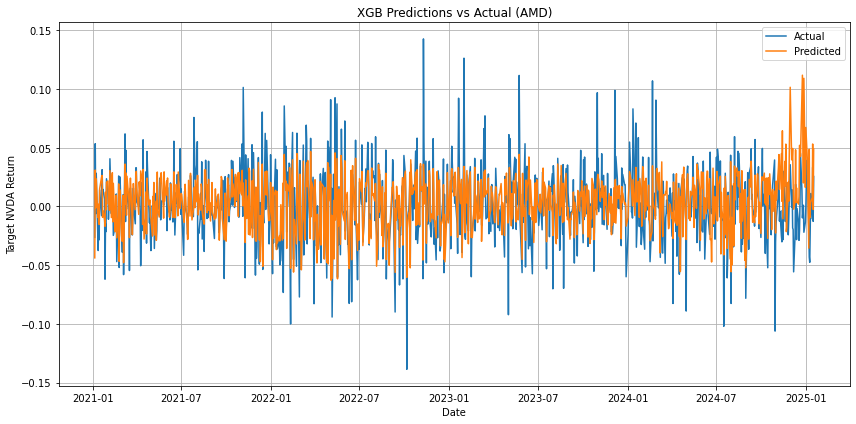

In [0]:
run_xgboost(df_stocks, df_stocks_test, 'target_amd_return', "AMD")

Below is the Granger test. It is commented out though as Linear Regression helped show that the patterns werent linear and Granger assumes linearity.

In [0]:
# feature_cols = [col for col in df_stocks.columns if col not in ("Date")]

# df_stocks = df_stocks.dropna(subset=feature_cols)
# for c in feature_cols:
#     df_stocks = df_stocks.filter(~isnan(col(c)))

# df_pd = df_stocks.select("target_nvda_return", 'target_amd_return').toPandas()

# grangercausalitytests(df_pd, maxlag=5)